In [2]:
# Level Diagram
#
# References 
# [1] Blasco X, Herrero JM, Sanchis J, Martínez M (2008) A new graphical 
#   visualization of n-dimensional Pareto front for decision-making in 
#   multiobjective optimization. Inf Sci 178(20):3908–3924 
#
# Created by 
# Mario Castro-Gama ir. MSc. PhD 
# 2016-09-05 
#
# Still to do 
# - Input verification and include more variables such as 
# + return also the levels for further evaluation (if required) 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [4]:
def level_diagram(XX):
    """
    Python translation of MATLAB function level_diagram

    Parameters
    ----------
    XX : ndarray (ndata, nobj)
        Matrix containing objectives

    Returns
    -------
    text with index row of best trade-off solution in input array XX

    References 
    [1] Blasco X, Herrero JM, Sanchis J, Martínez M (2008) A new graphical 
        visualization of n-dimensional Pareto front for decision-making in 
        multiobjective optimization. Inf Sci 178(20):3908–3924 
    
    Created by 
    Mario Castro-Gama ir. MSc. PhD 
    2016-09-05 
    
    Still to do 
    - Input verification and include more variables such as 
    + return also the levels for further evaluation (if required) 

    """

    XX = np.asarray(XX, dtype=float)
    ndata, nobj = XX.shape

    # ---- Plotting options ----
    OFnames, OFscales = create_fignames(nobj, prefix='F_')

    sel_fontname = "Palatino Linotype" #"Arial"
    sel_fontsize = 12
    sel_fontweight = "bold"
    ndecimals = 3

    # ---- Rescale objectives ----
    xmin = XX.min(axis=0)
    xmax = XX.max(axis=0)
    XX2 = rescale_objs(XX, mode="full")

    # ---- Norm of rescaled solutions ----
    norm_type = 2
    euc = norm_forall(XX2, norm_type)

    BTOmax = np.max(euc)
    BTOmin = np.min(euc)
    BTOpos = np.argmin(euc)

    # ---- Plot layout ----
    ncols = int(np.ceil(nobj / 2))
    hh = plt.figure(facecolor="white", figsize=(10, 5))

    for isub in range(nobj):
        ax = hh.add_subplot(2, ncols, isub + 1)

        # Scatter plot
        ax.plot(XX[:, isub], euc, '.', 
                markersize = 2, 
                mfc        = 'gray',
                label      = OFnames[isub])
        ax.plot(round(XX[BTOpos, isub], ndecimals), round(BTOmin, ndecimals), 'rs',
                mfc        = 'y',
                markersize = 10,
                alpha      = 0.5,
                label      = r'$BTO$')

        # Font settings
        #ax.set_xlabel(OFnames[isub], 
        #              fontname = sel_fontname,
        #              fontsize = sel_fontsize, 
        #              fontweight = sel_fontweight)
        ax.set_ylabel('2-norm' if isub % ncols == 0 else "",
                      fontname = sel_fontname,
                      fontsize = sel_fontsize,
                      fontweight = sel_fontweight)

        # X-axis
        ax.set_xscale(OFscales[isub])
        xticks = xmin[isub] + np.array([0.0, 0.5, 1.0]) * (xmax[isub] - xmin[isub])
        xticks = np.round(xticks, 3)
        #print(xticks)
        xdelta = 0.05*(xmax[isub] - xmin[isub])
        ax.set_xlim(round(xmin[isub]-xdelta, ndecimals), round(xmax[isub]+xdelta, ndecimals))
        ax.set_xticks(xticks)
        
        # Y-axis
        ax.set_yscale('linear')
        yticks = BTOmin + np.array([0.0, 0.25, 0.5, 0.75, 1.0]) * (BTOmax - BTOmin)
        yticks = np.round(yticks,3)
        #print(yticks)
        ydelta = 0.05*(BTOmax-BTOmin)
        ax.set_ylim(round(BTOmin-ydelta, ndecimals), round(BTOmax+ydelta, ndecimals))
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticks if isub % ncols ==0 else "")

        # legend       
        ax.legend(loc = 2)

        # Aspect and Grid
        ax.set_aspect('auto', 'box')
        ax.grid(True)

    plt.tight_layout()
    return 'Levels diagram, Best solution : '+str(BTOpos)+' (on current array size ['+str(ndata)+','+str(nobj)+'])'

In [5]:
def rescale_objs(X, mode = 'full'):
    X = np.asarray(X, dtype=float)
    if mode == 'full':
        return (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
    elif mode == 'max':
        return X / X.max(axis=0)
    else:
        raise ValueError('Unknown rescaling mode')

In [6]:
def norm_forall(X, p=2):
    return np.linalg.norm(X, ord=p, axis=1)

In [7]:
def create_fignames(nobj, prefix='obj'):
    names = [f"${prefix}{i+1}$" for i in range(nobj)]
    scales = ['linear'] * nobj
    return names, scales

## 1. WATER (Ray, Tai & Seow) Problem (5 Objectives)

In [34]:
df_water = pd.read_csv('WATER/WATER_NSGA2_500k.txt')

In [35]:
OF_water = df_water[['F_1','F_2','F_3','F_4','F_5']].to_numpy()
OF_water.shape


(499133, 5)

In [36]:
OF_water.shape[0] - 200**2

459133

'Levels diagram, Best solution : 11222 (on current array size [40000,5])'

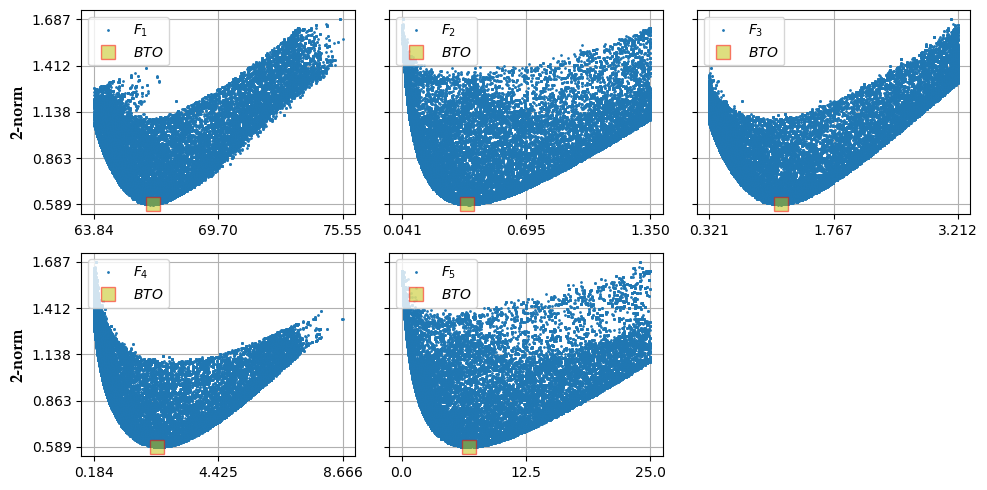

In [38]:
# ~40000 last solutions
OF_water_short = OFw[459133:,:]
level_diagram(OF_water_short)

## 3. Veldhuizen problem (8 Objectives)

In [28]:
df = pd.read_csv('veldhuizen/Veldhuizen_500k.txt')

# Include a column for the generation number
df.insert(0,'gen', np.floor(df.index/500))

# show the dataframe
df

,gen,F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,G_1,G_2,G_3,X_1,X_2
0,0.0,3.185007,-10.021180,16.301679,33.964750,-15.982831,104.104053,2.801634,5.197258,-0.017998,-1.094573,-5.509137,0.094573,3.603710
1,0.0,3.437599,-9.408725,17.372953,33.640398,-15.473515,105.198878,2.832317,5.514073,-0.627991,-0.881528,-5.964370,-0.118472,3.845898
2,0.0,4.126031,-12.072401,15.038190,32.824793,-15.745511,96.542821,3.559415,3.482400,-1.627314,-1.087111,-3.937131,0.087111,2.024242
3,0.0,7.479762,-12.609464,17.015970,29.605538,-16.278576,84.244930,7.308378,-0.450372,-9.461391,-0.001176,-1.532729,-0.998824,-1.466095
4,0.0,6.766669,-11.749626,15.879997,30.850864,-12.914512,95.285818,4.532210,3.253707,-6.024072,-0.043394,-4.758957,-0.956606,1.802352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499297,998.0,5.201759,-11.007670,16.217948,31.970123,-14.025966,99.042704,3.690486,4.149440,-3.512643,-0.462413,-5.175292,-0.537587,2.637705
499298,998.0,3.306984,-9.410483,17.257607,33.784167,-15.643218,105.371409,2.789758,5.531375,-0.389111,-0.934909,-5.936347,-0.065091,3.871255
499299,998.0,3.123292,-9.343293,17.200919,33.990968,-15.862734,105.779966,2.723912,5.599638,-0.060707,-0.999957,-5.939510,-0.000043,3.939467
499300,998.0,4.358967,-12.919467,16.562013,32.225603,-16.427160,90.699490,4.302392,2.090552,-2.457892,-1.236542,-2.359399,0.236542,0.595941


In [29]:
OFnames = ['F_1','F_2','F_3','F_4','F_5','F_6','F_7','F_8']
OF = df[OFnames].to_numpy()
OFshort = OF[494118:,:]

'Levels diagram, Best solution : 104 (on current array size [5184,8])'

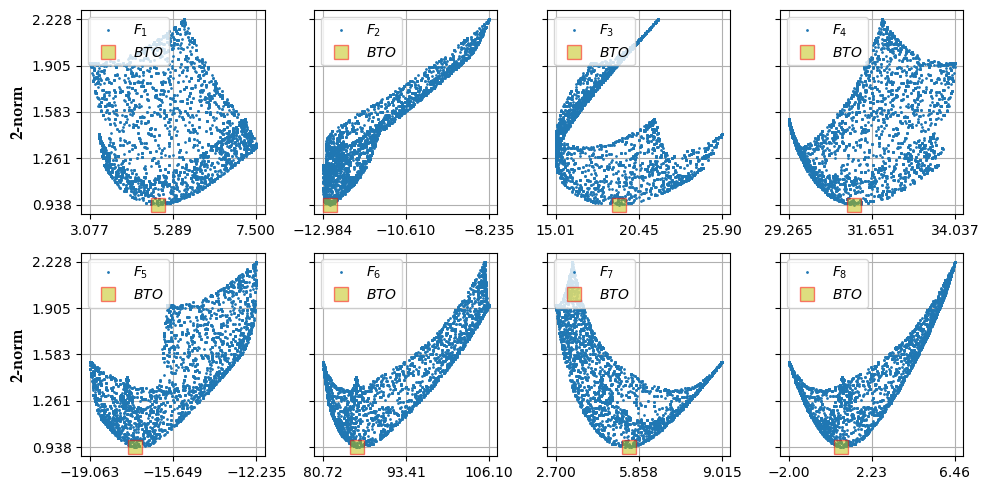

In [30]:
# ~5000 last solutions
level_diagram(OFshort)

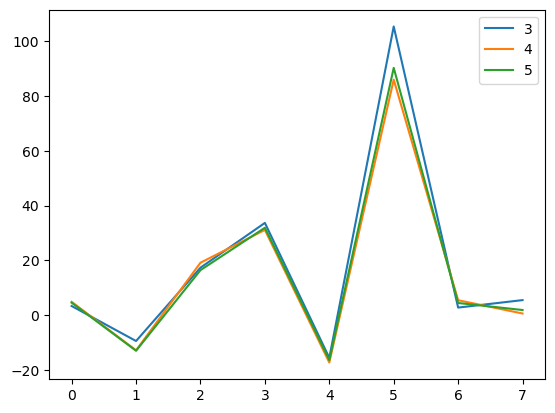

In [22]:
plt.plot(OFshort[103:106,:].T)
plt.legend(('3','4','5'))